In [1]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm


In [2]:
BASE_FILE = os.path.join("..", "..", "data", "processed", "cardio_onc_prostate_06_broad_clean.csv")

df = pd.read_csv(BASE_FILE)

print(df.shape)
df.head()

mapping = {
    # Orgovyx
    'orgovyx': 'Orgovyx',
    'orogovyx': 'Orgovyx',
    'orgovyx and nubeqa': 'Orgovyx',


    # Lupron
    'lupron': 'Lupron',
    'lupron depot': 'Lupron',
    'leupron': 'Lupron',
    'lupon': 'Lupron',
    'lpron': 'Lupron',

    # Bicalutamide / Casodex
    'bicalutamide': 'Bicalutamide',
    'casodex': 'Bicalutamide',

    # Firmagon
    'firmagon': 'Firmagon',

    # Multi / transitions / combos
    'firmagon to lupron': 'Lupron',
    'lupron + casodex to lupron': 'Lupron',
    'lupron, orgovyx (d/c)': 'Lupron',
    'firmagon to orgovyx': 'Orgovyx',
    'lupron, firmagon': 'Lupron',
    'bicalutamide + lupron': 'Lupron',
    'bicalutamide, then lupron': 'Lupron',
    'casodex to lpron': 'Lupron',
    'bicalutamide to lupron to orgovyx': 'Orgovyx',
    'lupron + bicalutamide': 'Lupron',
    'lupron to orgovyx': 'Orgovyx',
    'bicalutamide to lupron': 'Lupron',
    'casodex to lupron': 'Lupron',
    'casodex to firmagon': 'Firmagon'
}

# Apply mapping
df["adt_agent"] = df["adt_agent"].replace(mapping)

(239, 60)


In [3]:
# document missingness
na_count = df["hx_htn"].isna().sum()
na_pct = na_count / len(df) * 100

print(f"Missing hx_htn: {na_count} ({na_pct:.1f}%) out of {len(df)} patients")

Missing hx_htn: 39 (16.3%) out of 239 patients


In [4]:
# prevalence

valid_htn = df["hx_htn"].notna()

n_total = valid_htn.sum()
n_htn = df.loc[valid_htn, "hx_htn"].sum()
pct_htn = n_htn / n_total * 100

print(f"Overall hx_htn prevalence: {n_htn}/{n_total} ({pct_htn:.1f}%) [excluding missing]")

Overall hx_htn prevalence: 118.0/200 (59.0%) [excluding missing]


In [5]:
# treatment patterns
htn_df = df[df["hx_htn"] == 1]

# counts and percentages
nht_counts = htn_df["specific_nht_used"].value_counts()
nht_pct = htn_df["specific_nht_used"].value_counts(normalize=True) * 100

# risk rate (mean of binary outcome = proportion at_risk = 1)
risk_rate = htn_df.groupby("specific_nht_used")["at_risk"].mean() * 100

# combine into one table
treatment_table = pd.DataFrame({
    "count": nht_counts,
    "percent": nht_pct.round(1),
    "risk_rate (%)": risk_rate.round(1)
})

# sort (optional, keeps consistent order)
treatment_table = treatment_table.sort_values(by="count", ascending=False)

print("\nNHT agent distribution among hypertensive patients:")
print(treatment_table)


NHT agent distribution among hypertensive patients:
                   count  percent  risk_rate (%)
specific_nht_used                               
Abiraterone           55     46.6           52.7
Darolutamide          46     39.0           39.1
Enzalutamide           9      7.6           33.3
Apalutamide            8      6.8           37.5


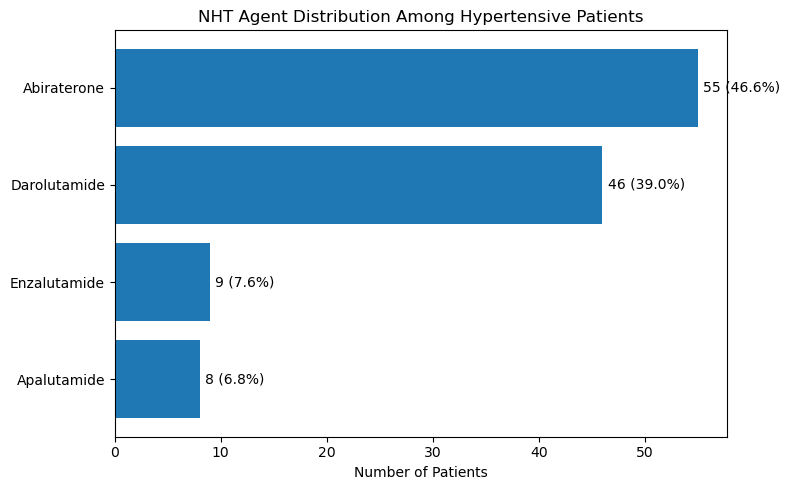

In [6]:
# plot treatment patterns
htn_df = df[df["hx_htn"] == 1]

agent_counts = htn_df["specific_nht_used"].value_counts()
agent_pct = htn_df["specific_nht_used"].value_counts(normalize=True) * 100

agent_counts = agent_counts.sort_values(ascending=False)
agent_pct = agent_pct[agent_counts.index]

plt.figure(figsize=(8, 5))

bars = plt.barh(agent_counts.index, agent_counts.values)

plt.gca().invert_yaxis()

for i, agent in enumerate(agent_counts.index):
    count = agent_counts[agent]
    pct = agent_pct[agent]
    plt.text(count + 0.5, i, f"{count} ({pct:.1f}%)", va="center")

plt.xlabel("Number of Patients")
plt.title("NHT Agent Distribution Among Hypertensive Patients")

plt.tight_layout()
plt.show()

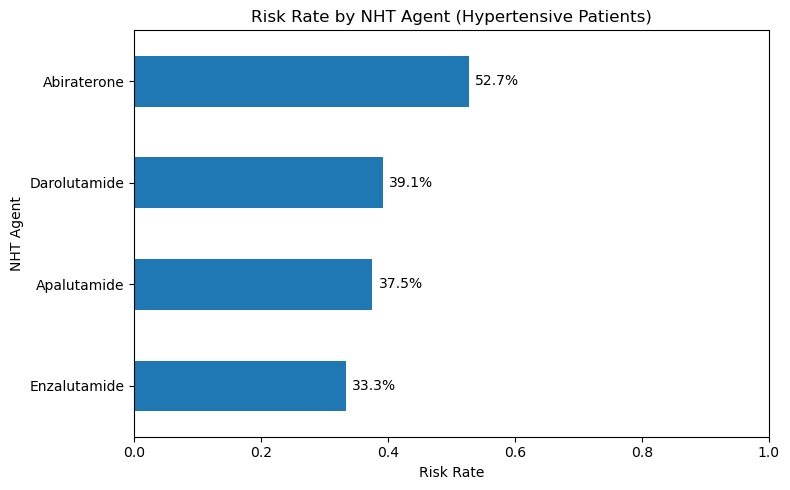

In [7]:

# subset to hypertensive patients
htn_df = df[df["hx_htn"] == 1]

# compute risk rates
risk_by_nht = (
    htn_df.groupby("specific_nht_used")["at_risk"]
    .mean()
    .sort_values(ascending=True)  # ascending works better for horizontal bars
)

# plot (horizontal)
ax = risk_by_nht.plot(kind="barh", figsize=(8,5))

ax.set_title("Risk Rate by NHT Agent (Hypertensive Patients)")
ax.set_ylabel("NHT Agent")
ax.set_xlabel("Risk Rate")

# set x-axis from 0 to 1 (since it's a proportion)
ax.set_xlim(0, 1)

# annotate bars
for i, v in enumerate(risk_by_nht):
    ax.text(v + 0.01, i, f"{v*100:.1f}%", va="center")

plt.tight_layout()
plt.show()

In [8]:
# table: risk rates by hx_htn

counts = pd.crosstab(df["hx_htn"], df["at_risk"]).reindex([0, 1])

percents = counts.div(counts.sum(axis=1), axis=0) * 100

table = counts.astype(str) + " (" + percents.round(1).astype(str) + "%)"

table.index = ["hx_htn = 0", "hx_htn = 1"]

table

at_risk,0.0,1.0
hx_htn = 0,57 (69.5%),25 (30.5%)
hx_htn = 1,65 (55.1%),53 (44.9%)


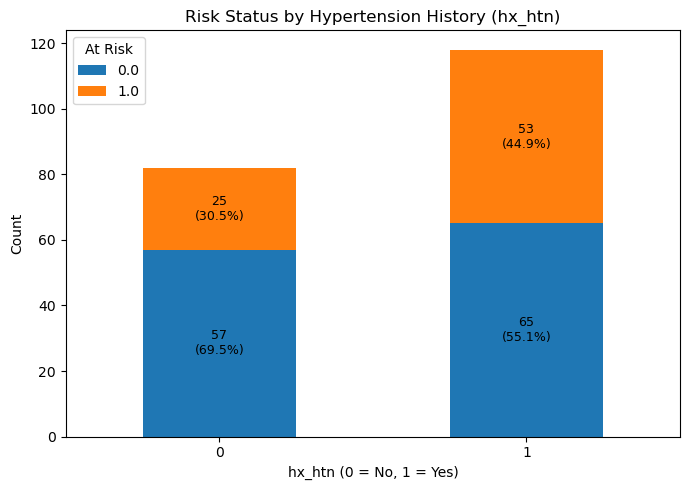

In [9]:
# plot: risk rates by hx_htn

ct = pd.crosstab(df["hx_htn"], df["at_risk"]).reindex([0, 1])

ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

ax = ct.plot(kind="bar", stacked=True, figsize=(7,5))

ax.set_title("Risk Status by Hypertension History (hx_htn)")
ax.set_xlabel("hx_htn (0 = No, 1 = Yes)")
ax.set_ylabel("Count")
ax.set_xticklabels(["0", "1"], rotation=0)
plt.legend(title="At Risk")

for i, idx in enumerate(ct.index):
    bottom = 0
    for j, col in enumerate(ct.columns):
        value = ct.loc[idx, col]
        pct = ct_pct.loc[idx, col]

        if value > 0:
            ax.text(
                i,
                bottom + value / 2,
                f"{value}\n({pct:.1f}%)",
                ha="center",
                va="center",
                fontsize=9
            )
        bottom += value

plt.tight_layout()
plt.show()

In [10]:
# Chi Square test - hx_htn and at_risk

table = pd.crosstab(df["hx_htn"], df["at_risk"])
table

from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

expected_df = pd.DataFrame(expected, 
                            index=table.index, 
                            columns=table.columns)

expected_df


Chi-square statistic: 3.648292964430915
p-value: 0.05612670974056949
Degrees of freedom: 1


at_risk,0.0,1.0
hx_htn,,
0.0,50.02,31.98
1.0,71.98,46.02


In [11]:
# Fisher's exact test hx_htn and at_risk

from scipy.stats import fisher_exact

oddsratio, p_fisher = fisher_exact(table)

print("Odds ratio:", oddsratio)
print("Fisher p-value:", p_fisher)

Odds ratio: 1.859076923076923
Fisher p-value: 0.055008905758340595


In [12]:
# Chi Square test by NHT within hypertensive patients

htn_df = df[df["hx_htn"] == 1]
table_htn = pd.crosstab(htn_df["specific_nht_used"], htn_df["at_risk"])
print(table_htn)

chi2, p, dof, expected = chi2_contingency(table_htn)
print("----")
print("Chi-square statistic:", chi2)
print("p-value:", p)
print("degrees of freedom:", dof)

at_risk            0.0  1.0
specific_nht_used          
Abiraterone         26   29
Apalutamide          5    3
Darolutamide        28   18
Enzalutamide         6    3
----
Chi-square statistic: 2.6445600830670575
p-value: 0.4497310865905908
degrees of freedom: 3


In [13]:
import statsmodels.formula.api as smf

model = smf.logit(
    "at_risk ~ hx_htn * C(specific_nht_used)",
    data=df
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.650321
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                at_risk   No. Observations:                  200
Model:                          Logit   Df Residuals:                      192
Method:                           MLE   Df Model:                            7
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                 0.02755
Time:                        00:32:25   Log-Likelihood:                -130.06
converged:                       True   LL-Null:                       -133.75
Covariance Type:            nonrobust   LLR p-value:                    0.3913
                                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
Intercept                                 

In [14]:
# Was treatment choice (NHT agent) influenced by hypertension status?
# / Is specific_nht_used associated with hx_htn?

table = pd.crosstab(df["hx_htn"], df["specific_nht_used"])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)
print("dof:", dof)

print("\nExpected counts:")
print(pd.DataFrame(expected, index=table.index, columns=table.columns))

Chi-square: 1.6173411236617
p-value: 0.6554642596409901
dof: 3

Expected counts:
specific_nht_used  Abiraterone  Apalutamide  Darolutamide  Enzalutamide
hx_htn                                                                 
0.0                      36.08         5.33          32.8          7.79
1.0                      51.92         7.67          47.2         11.21


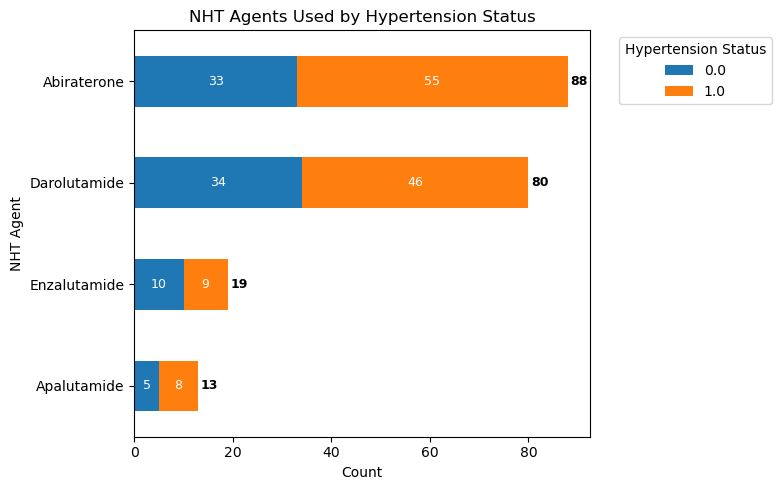

In [15]:

# contingency table (counts)
ct = pd.crosstab(df["specific_nht_used"], df["hx_htn"])

# reorder rows by TOTAL bar size (ascending)
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=True).index]

# plot
ax = ct.plot(kind="barh", stacked=True, figsize=(8,5))

# add segment labels
for i, (index, row) in enumerate(ct.iterrows()):
    left = 0
    for col in ct.columns:
        value = row[col]
        if value > 0:
            ax.text(left + value/2, i, str(value),
                    ha='center', va='center', fontsize=9, color='white')
        left += value

# (optional) add total at end of each bar
totals = ct.sum(axis=1)
for i, total in enumerate(totals):
    ax.text(total + 0.5, i, str(total),
            va='center', fontsize=9, fontweight='bold')

# labels
ax.set_title("NHT Agents Used by Hypertension Status")
ax.set_ylabel("NHT Agent")
ax.set_xlabel("Count")

plt.legend(title="Hypertension Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

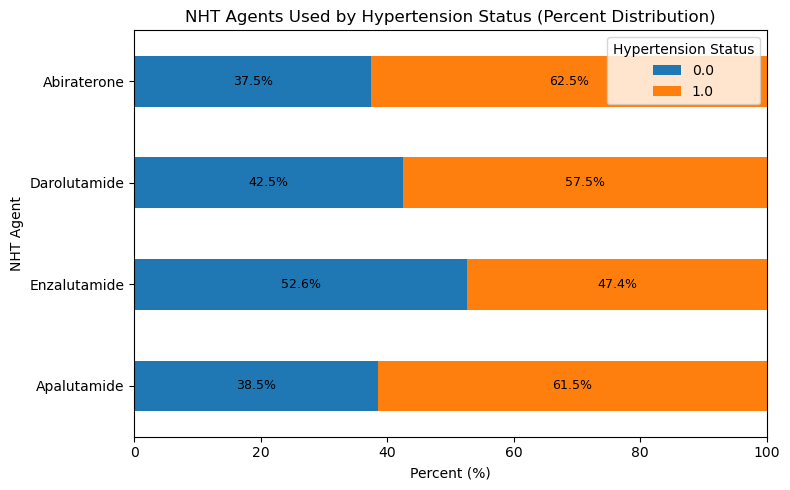

In [16]:

# contingency table (counts)
ct = pd.crosstab(df["specific_nht_used"], df["hx_htn"])

# reorder by total bar size (descending)
ct["Total"] = ct.sum(axis=1)
ct = ct.sort_values("Total", ascending=True).drop(columns="Total")

# convert to row-wise percentages
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

# plot horizontal stacked percentage bar chart
ax = ct_pct.plot(kind="barh", stacked=True, figsize=(8,5))

# labels
ax.set_title("NHT Agents Used by Hypertension Status (Percent Distribution)")
ax.set_xlabel("Percent (%)")
ax.set_ylabel("NHT Agent")

plt.legend(title="Hypertension Status")

# annotate percentages
for i, idx in enumerate(ct_pct.index):
    left = 0
    for col in ct_pct.columns:
        val = ct_pct.loc[idx, col]
        ax.text(left + val/2, i, f"{val:.1f}%", va="center", ha="center", fontsize=9)
        left += val

plt.xlim(0, 100)
plt.tight_layout()
plt.show()

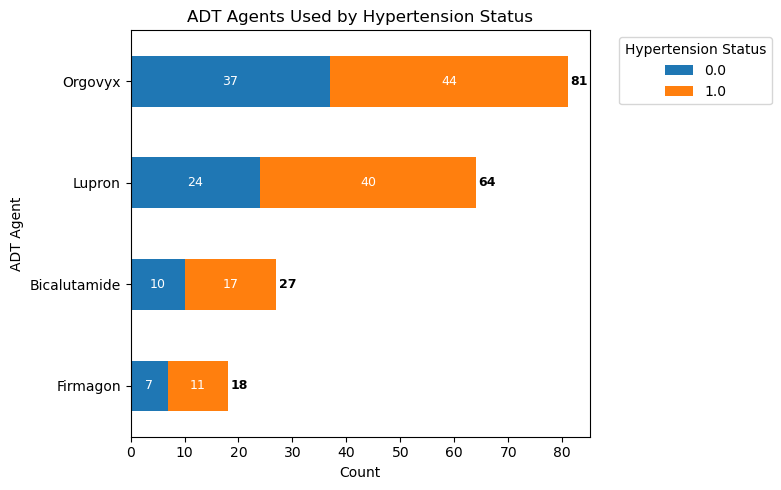

In [17]:

mapping = {
    # Orgovyx
    'orgovyx': 'Orgovyx',
    'orogovyx': 'Orgovyx',
    'orgovyx and nubeqa': 'Orgovyx',


    # Lupron
    'lupron': 'Lupron',
    'lupron depot': 'Lupron',
    'leupron': 'Lupron',
    'lupon': 'Lupron',
    'lpron': 'Lupron',

    # Bicalutamide / Casodex
    'bicalutamide': 'Bicalutamide',
    'casodex': 'Bicalutamide',

    # Firmagon
    'firmagon': 'Firmagon',

    # Multi / transitions / combos
    'firmagon to lupron': 'Lupron',
    'lupron + casodex to lupron': 'Lupron',
    'lupron, orgovyx (d/c)': 'Lupron',
    'firmagon to orgovyx': 'Orgovyx',
    'lupron, firmagon': 'Lupron',
    'bicalutamide + lupron': 'Lupron',
    'bicalutamide, then lupron': 'Lupron',
    'casodex to lpron': 'Lupron',
    'bicalutamide to lupron to orgovyx': 'Orgovyx',
    'lupron + bicalutamide': 'Lupron',
    'lupron to orgovyx': 'Orgovyx',
    'bicalutamide to lupron': 'Lupron',
    'casodex to lupron': 'Lupron',
    'casodex to firmagon': 'Firmagon'
}

# Apply mapping
df["adt_agent"] = df["adt_agent"].replace(mapping)

# contingency table (counts)
ct = pd.crosstab(df["adt_agent"], df["hx_htn"])

# reorder rows by TOTAL bar size (ascending)
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=True).index]

# plot
ax = ct.plot(kind="barh", stacked=True, figsize=(8,5))

# add segment labels
for i, (index, row) in enumerate(ct.iterrows()):
    left = 0
    for col in ct.columns:
        value = row[col]
        if value > 0:
            ax.text(left + value/2, i, str(value),
                    ha='center', va='center', fontsize=9, color='white')
        left += value

# (optional) add total at end of each bar
totals = ct.sum(axis=1)
for i, total in enumerate(totals):
    ax.text(total + 0.5, i, str(total),
            va='center', fontsize=9, fontweight='bold')

# labels
ax.set_title("ADT Agents Used by Hypertension Status")
ax.set_ylabel("ADT Agent")
ax.set_xlabel("Count")

plt.legend(title="Hypertension Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

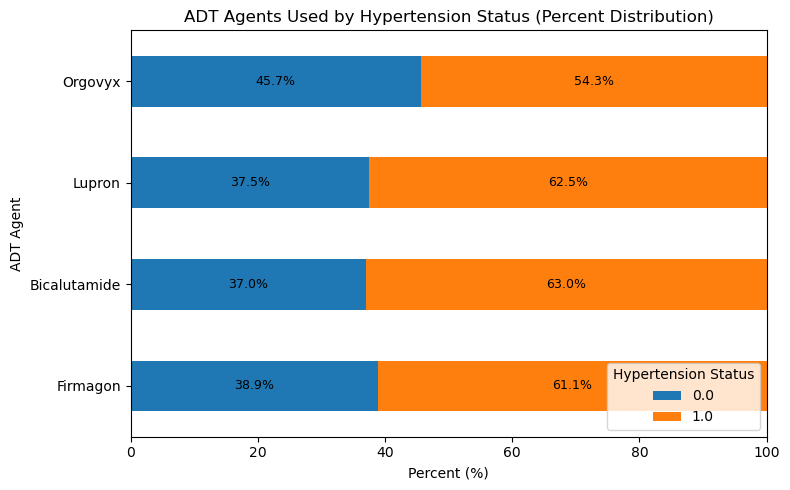

In [18]:

# contingency table (counts)
ct = pd.crosstab(df["adt_agent"], df["hx_htn"])

# reorder by total bar size (descending)
ct["Total"] = ct.sum(axis=1)
ct = ct.sort_values("Total", ascending=True).drop(columns="Total")

# convert to row-wise percentages
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

# plot horizontal stacked percentage bar chart
ax = ct_pct.plot(kind="barh", stacked=True, figsize=(8,5))

# labels
ax.set_title("ADT Agents Used by Hypertension Status (Percent Distribution)")
ax.set_xlabel("Percent (%)")
ax.set_ylabel("ADT Agent")

plt.legend(title="Hypertension Status")

# annotate percentages
for i, idx in enumerate(ct_pct.index):
    left = 0
    for col in ct_pct.columns:
        val = ct_pct.loc[idx, col]
        ax.text(left + val/2, i, f"{val:.1f}%", va="center", ha="center", fontsize=9)
        left += val

plt.xlim(0, 100)
plt.tight_layout()
plt.show()

In [19]:
model = smf.logit(
    "hx_htn ~  C(adt_agent) + C(specific_nht_used)",
    data=df
).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.669028
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:                 hx_htn   No. Observations:                  190
Model:                          Logit   Df Residuals:                      183
Method:                           MLE   Df Model:                            6
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                 0.01185
Time:                        00:32:25   Log-Likelihood:                -127.12
converged:                       True   LL-Null:                       -128.64
Covariance Type:            nonrobust   LLR p-value:                    0.8028
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                                0.6977      0.4

In [20]:
from scipy.stats import chi2_contingency

# contingency table
table_adt = pd.crosstab(df["hx_htn"], df["adt_agent"])

chi2, p, dof, expected = chi2_contingency(table_adt)

print("=== Chi-square test: hx_htn vs ADT agent ===")
print(f"Chi2 statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p:.6f}")

=== Chi-square test: hx_htn vs ADT agent ===
Chi2 statistic: 1.2649
Degrees of freedom: 3
P-value: 0.737475


In [21]:
# contingency table
table_nht = pd.crosstab(df["hx_htn"], df["specific_nht_used"])

chi2, p, dof, expected = chi2_contingency(table_nht)

print("=== Chi-square test: hx_htn vs NHT agent ===")
print(f"Chi2 statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p:.6f}")

=== Chi-square test: hx_htn vs NHT agent ===
Chi2 statistic: 1.6173
Degrees of freedom: 3
P-value: 0.655464


In [22]:

predictor = "bp_meds_prior"
response = "adt_agent"

df_model = df[[response, predictor]].dropna().copy()

y = df_model[response].astype(str)

X = df_model[[predictor]]
X = sm.add_constant(X)

model_adt = sm.MNLogit(y, X).fit()

print(model_adt.summary())

Optimization terminated successfully.
         Current function value: 1.198812
         Iterations 6
                          MNLogit Regression Results                          
Dep. Variable:              adt_agent   No. Observations:                  192
Model:                        MNLogit   Df Residuals:                      186
Method:                           MLE   Df Model:                            3
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                 0.02259
Time:                        00:32:26   Log-Likelihood:                -230.17
converged:                       True   LL-Null:                       -235.49
Covariance Type:            nonrobust   LLR p-value:                   0.01383
adt_agent=Firmagon       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.4098      0.446      0.918      0.358      -0.465       1.284
bp_me

In [23]:
binary_features = [
    "hx_smoking", "family_hx_hd", "hx_htn",
    "bp_meds_prior", "bb_prior", "ace_arb_prior",
    "has_pcp", "hx_hld", "hx_high_tg",
    "statin_prior", "other_lipid_prior", "lipid_panel_checked",
    "hx_cad", "hx_mi_stent", "hx_chf", "hx_arrhythmia",
    "hx_carotid", "hx_pad", "hx_cva",
    "hx_dm2", "dm_noninsulin", "on_insulin",
    "a1c_checked", "glucose_over_200",
    "asa_use", "cards_prior", "cards_post", "cards_referral",
    "diet_counseling", "exercise_counseling",
    "echo_ordered", "ecg_done", "non_onc_provider",
]


results = []

for var in binary_features:
    try:
        df_tmp = df[["adt_agent", var]].dropna()
        
        X = sm.add_constant(df_tmp[[var]])
        y = df_tmp["adt_agent"].astype(str)
        
        model = sm.MNLogit(y, X).fit(disp=0)
        
        results.append({
            "feature": var,
            "p_value": model.pvalues.iloc[1].min(),
        })
    except:
        continue

pd.DataFrame(results).sort_values("p_value")

c:\Users\Trian\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Trian\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Trian\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Trian\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Trian\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximu

,feature,p_value
26,cards_post,0.001800
30,echo_ordered,0.008509
12,hx_cad,0.009119
24,asa_use,0.009723
3,bp_meds_prior,0.017316
22,a1c_checked,0.031431
13,hx_mi_stent,0.035162
18,hx_cva,0.048159
32,non_onc_provider,0.081053
14,hx_chf,0.085117


# Provider Bias

In [24]:
# Which features are related to NHT choice?

continuous_features = [
    "bmi", "age", "sbp", "dbp", "ascvd_10yr",
    "days_auth_to_start", "days_adt_to_nht",
]

binary_features = [
    "hx_smoking", "family_hx_hd", "hx_htn",
    "bp_meds_prior", "bb_prior", "ace_arb_prior",
    "has_pcp", "hx_hld", "hx_high_tg",
    "statin_prior", "other_lipid_prior", "lipid_panel_checked",
    "hx_cad", "hx_mi_stent", "hx_chf", "hx_arrhythmia",
    "hx_carotid", "hx_pad", "hx_cva",
    "hx_dm2", "dm_noninsulin", "on_insulin",
    "a1c_checked", "glucose_over_200",
    "asa_use", "cards_prior", "cards_post", "cards_referral",
    "diet_counseling", "exercise_counseling",
    "echo_ordered", "ecg_done", "non_onc_provider",
]

encoded_features = [
    "ethnicity_enc",
    "adt_agent_enc", "prescribing_provider_enc",
]

all_features = continuous_features + binary_features + encoded_features


results = []

for var in all_features:
    try:
        df_tmp = df[["specific_nht_used", var]].dropna()

        X = sm.add_constant(df_tmp[[var]])
        y = df_tmp["specific_nht_used"].astype(str)

        model = sm.MNLogit(y, X).fit(disp=0)

        results.append({
            "feature": var,
            "p_value": model.llr_pvalue
        })

    except:
        continue

df_result = pd.DataFrame(results)

df_result[df_result["p_value"] < 0.05].sort_values("p_value")

c:\Users\Trian\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Trian\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Trian\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Trian\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Trian\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximu

,feature,p_value
1,age,0.000388
39,adt_agent_enc,0.023865
38,ethnicity_enc,0.026749
14,statin_prior,0.030953
26,on_insulin,0.043954
4,ascvd_10yr,0.044037


                          MNLogit Regression Results                          
Dep. Variable:      specific_nht_used   No. Observations:                  203
Model:                        MNLogit   Df Residuals:                      197
Method:                           MLE   Df Model:                            3
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                 0.01943
Time:                        00:32:27   Log-Likelihood:                -224.01
converged:                       True   LL-Null:                       -228.45
Covariance Type:            nonrobust   LLR p-value:                   0.03095
 specific_nht_used=Apalutamide       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -1.9661      0.404     -4.872      0.000      -2.757      -1.175
statin_prior                       0.0943      0.596      0.158      0.

<Axes: xlabel='statin_prior'>

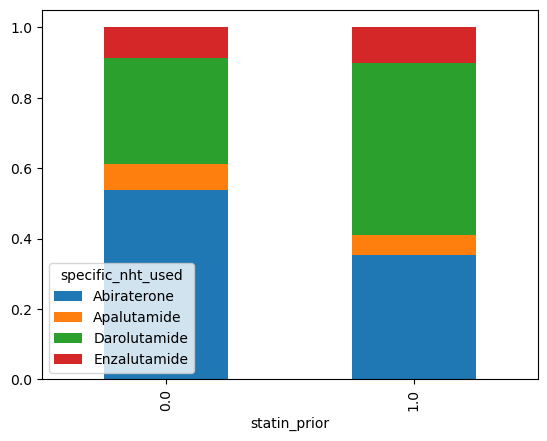

In [25]:
# Statin prior -> NHT received

df_tmp = df[["specific_nht_used", "statin_prior"]].dropna()

X = sm.add_constant(df_tmp[["statin_prior"]])
y = df_tmp["specific_nht_used"].astype(str)

model = sm.MNLogit(y, X).fit(disp=0)

print(model.summary())

pd.crosstab(df["statin_prior"], df["specific_nht_used"], normalize="index").plot(kind="bar", stacked=True)


                          MNLogit Regression Results                          
Dep. Variable:      specific_nht_used   No. Observations:                  200
Model:                        MNLogit   Df Residuals:                      194
Method:                           MLE   Df Model:                            3
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                 0.01794
Time:                        00:32:27   Log-Likelihood:                -221.76
converged:                       True   LL-Null:                       -225.81
Covariance Type:            nonrobust   LLR p-value:                   0.04395
 specific_nht_used=Apalutamide       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -1.9095      0.309     -6.173      0.000      -2.516      -1.303
on_insulin                        -0.0364      1.113     -0.033      0.

<Axes: xlabel='on_insulin'>

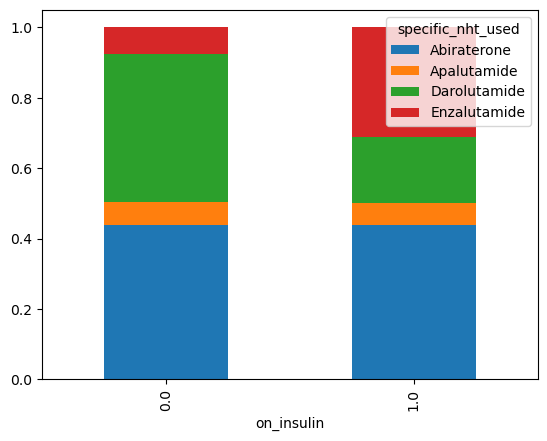

In [26]:
# On insulin -> NHT received


df_tmp = df[["specific_nht_used", "on_insulin"]].dropna()

X = sm.add_constant(df_tmp[["on_insulin"]])
y = df_tmp["specific_nht_used"].astype(str)

model = sm.MNLogit(y, X).fit(disp=0)

print(model.summary())

pd.crosstab(df["on_insulin"], df["specific_nht_used"], normalize="index").plot(kind="bar", stacked=True)


                          MNLogit Regression Results                          
Dep. Variable:      specific_nht_used   No. Observations:                  207
Model:                        MNLogit   Df Residuals:                      201
Method:                           MLE   Df Model:                            3
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                 0.03858
Time:                        00:32:27   Log-Likelihood:                -227.61
converged:                       True   LL-Null:                       -236.74
Covariance Type:            nonrobust   LLR p-value:                 0.0003877
 specific_nht_used=Apalutamide       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -5.1254      2.453     -2.090      0.037      -9.933      -0.318
age                                0.0465      0.034      1.368      0.

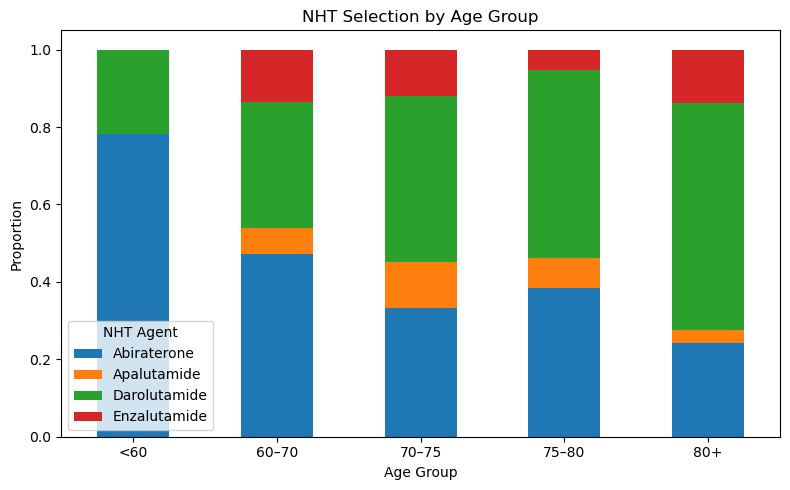

In [27]:
# Age -> NHT received

df_tmp = df[["specific_nht_used", "age"]].dropna()

X = sm.add_constant(df_tmp[["age"]])
y = df_tmp["specific_nht_used"].astype(str)

model = sm.MNLogit(y, X).fit(disp=0)

print(model.summary())

df_plot = df[["age", "specific_nht_used"]].dropna().copy()

df_plot["age_group"] = pd.cut(
    df_plot["age"],
    bins=[0, 60, 70, 75, 80, 100],
    labels=["<60", "60–70", "70–75", "75–80", "80+"]
)

ct = pd.crosstab(
    df_plot["age_group"],
    df_plot["specific_nht_used"],
    normalize="index"
)

ax = ct.plot(kind="bar", stacked=True, figsize=(8,5))

ax.set_title("NHT Selection by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Proportion")

plt.xticks(rotation=0)
plt.legend(title="NHT Agent")
plt.tight_layout()
plt.show()

In [28]:
# ADT -> NHT received

df_tmp = df[["specific_nht_used", "adt_agent_enc"]].dropna()

X = sm.add_constant(df_tmp[["adt_agent_enc"]])
y = df_tmp["specific_nht_used"].astype(str)

model = sm.MNLogit(y, X).fit(disp=0)

print(model.summary())

                          MNLogit Regression Results                          
Dep. Variable:      specific_nht_used   No. Observations:                  195
Model:                        MNLogit   Df Residuals:                      189
Method:                           MLE   Df Model:                            3
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                 0.02135
Time:                        00:32:28   Log-Likelihood:                -216.55
converged:                       True   LL-Null:                       -221.28
Covariance Type:            nonrobust   LLR p-value:                   0.02387
 specific_nht_used=Apalutamide       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -1.0768      0.477     -2.256      0.024      -2.012      -0.141
adt_agent_enc                     -0.4470      0.240     -1.862      0.

In [29]:
# Which features are related to ADT choice?

continuous_features = [
    "bmi", "age", "sbp", "dbp", "ascvd_10yr",
    "days_auth_to_start", "days_adt_to_nht",
]

binary_features = [
    "hx_smoking", "family_hx_hd", "hx_htn",
    "bp_meds_prior", "bb_prior", "ace_arb_prior",
    "has_pcp", "hx_hld", "hx_high_tg",
    "statin_prior", "other_lipid_prior", "lipid_panel_checked",
    "hx_cad", "hx_mi_stent", "hx_chf", "hx_arrhythmia",
    "hx_carotid", "hx_pad", "hx_cva",
    "hx_dm2", "dm_noninsulin", "on_insulin",
    "a1c_checked", "glucose_over_200",
    "asa_use", "cards_prior", "cards_post", "cards_referral",
    "diet_counseling", "exercise_counseling",
    "echo_ordered", "ecg_done", "non_onc_provider",
]

encoded_features = [
    "ethnicity_enc", "prescribing_provider_enc",
]

all_features = continuous_features + binary_features + encoded_features


results = []

for var in all_features:
    try:
        df_tmp = df[["adt_agent", var]].dropna()

        X = sm.add_constant(df_tmp[[var]])
        y = df_tmp["adt_agent"].astype(str)

        model = sm.MNLogit(y, X).fit(disp=0)

        results.append({
            "feature": var,
            "p_value": model.llr_pvalue
        })

    except:
        continue

df_result = pd.DataFrame(results)

df_result[df_result["p_value"] < 0.05].sort_values("p_value")

c:\Users\Trian\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Trian\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Trian\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Trian\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Trian\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximu

,feature,p_value
16,lipid_panel_checked,0.003732
31,cards_post,0.004770
13,hx_high_tg,0.010041
8,bp_meds_prior,0.013833
17,hx_cad,0.016638
34,exercise_counseling,0.027958
2,sbp,0.031748
35,echo_ordered,0.033174


In [30]:

df_tmp = df[["adt_agent", "bp_meds_prior"]].dropna()

X = sm.add_constant(df_tmp[["bp_meds_prior"]])
y = df_tmp["adt_agent"].astype(str)

model = sm.MNLogit(y, X).fit(disp=0)

print(model.summary())

                          MNLogit Regression Results                          
Dep. Variable:              adt_agent   No. Observations:                  192
Model:                        MNLogit   Df Residuals:                      186
Method:                           MLE   Df Model:                            3
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                 0.02259
Time:                        00:32:29   Log-Likelihood:                -230.17
converged:                       True   LL-Null:                       -235.49
Covariance Type:            nonrobust   LLR p-value:                   0.01383
adt_agent=Firmagon       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.4098      0.446      0.918      0.358      -0.465       1.284
bp_meds_prior         -0.9574      0.402     -2.380      0.017      -1.746      -0.169
--------------------

In [31]:

df_tmp = df[["adt_agent", "hx_cad"]].dropna()

X = sm.add_constant(df_tmp[["hx_cad"]])
y = df_tmp["adt_agent"].astype(str)

model = sm.MNLogit(y, X).fit(disp=0)

print(model.summary())

                          MNLogit Regression Results                          
Dep. Variable:              adt_agent   No. Observations:                  191
Model:                        MNLogit   Df Residuals:                      185
Method:                           MLE   Df Model:                            3
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                 0.02182
Time:                        00:32:29   Log-Likelihood:                -229.53
converged:                       True   LL-Null:                       -234.65
Covariance Type:            nonrobust   LLR p-value:                   0.01664
adt_agent=Firmagon       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.3054      0.352     -0.867      0.386      -0.996       0.385
hx_cad                -0.3878      0.706     -0.549      0.583      -1.772       0.997
--------------------

In [32]:

df_tmp = df[["adt_agent", "sbp"]].dropna()

X = sm.add_constant(df_tmp[["sbp"]])
y = df_tmp["adt_agent"].astype(str)

model = sm.MNLogit(y, X).fit(disp=0)

print(model.summary())

                          MNLogit Regression Results                          
Dep. Variable:              adt_agent   No. Observations:                  141
Model:                        MNLogit   Df Residuals:                      135
Method:                           MLE   Df Model:                            3
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                 0.02748
Time:                        00:32:29   Log-Likelihood:                -156.12
converged:                       True   LL-Null:                       -160.53
Covariance Type:            nonrobust   LLR p-value:                   0.03175
adt_agent=Firmagon       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  4.3912      3.414      1.286      0.198      -2.300      11.083
sbp                   -0.0372      0.026     -1.437      0.151      -0.088       0.014
--------------------